In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Density measurement (Numerical data) - Density parabolic fitting .csv to Density measurement (Numerical data) - Density parabolic fitting  (1).csv


In [11]:
df = pd.read_csv("Density measurement (Numerical data) - Density parabolic fitting  (1).csv")

df.head()

,B1,B2,∆f,intercept,Measured density (x),Density of Fluid,Error%,Unnamed: 7,Sensitivity,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Density,Freq,Unnamed: 16,Freq shift
0,0.20065,-0.000036,97.53,5.4216,505.0,500,-1.08,NaN,NaN,505.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1162.0
1,0.20065,-0.000036,99.17,5.4216,515.0,510,-1.06,NaN,NaN,515.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1162.0
2,0.20065,-0.000036,100.80,5.4216,525.0,520,-1.04,NaN,NaN,525.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1162.0
3,0.20065,-0.000036,102.42,5.4216,535.0,530,-1.02,NaN,NaN,535.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1162.0
4,0.20065,-0.000036,104.03,5.4216,545.0,540,-1.00,NaN,NaN,545.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1162.0


In [12]:
data = df[['∆f', 'Density of Fluid']]

data = data.dropna()

data.head()

,∆f,Density of Fluid
0,97.53,500
1,99.17,510
2,100.80,520
3,102.42,530
4,104.03,540


In [13]:
# =====================================================
# CELL 6: Define Input (X) and Output (y)
# =====================================================
# X -> Independent variable (frequency shift)
# y -> Dependent variable (fluid density)

X = data[['∆f']]
y = data['Density of Fluid']

In [14]:
# =====================================================
# CELL 7: Create Polynomial Features
# =====================================================
# Since the relation between frequency shift and density
# is parabolic, we convert the feature into polynomial form

poly = PolynomialFeatures(degree=2)

# Transform the input feature
X_poly = poly.fit_transform(X)

# Display first few transformed rows
X_poly[:5]

array([[1.00000000e+00, 9.75300000e+01, 9.51210090e+03],
       [1.00000000e+00, 9.91700000e+01, 9.83468890e+03],
       [1.00000000e+00, 1.00800000e+02, 1.01606400e+04],
       [1.00000000e+00, 1.02420000e+02, 1.04898564e+04],
       [1.00000000e+00, 1.04030000e+02, 1.08222409e+04]])

In [15]:
# this is converted :   Δf → [1, Δf, (Δf)²]

In [16]:
# =====================================================
# CELL 8: Train Polynomial Regression Model
# =====================================================
# LinearRegression is used after polynomial transformation
# to learn the parabolic relationship in the data

model = LinearRegression()

# Fit model on transformed dataset
model.fit(X_poly, y)

LinearRegression()

In [17]:
# =====================================================
# CELL 9: Generate Predictions
# =====================================================
# The trained model is used to predict density
# values based on frequency shift

y_pred = model.predict(X_poly)

# Display first few predicted values
y_pred[:5]

array([503.68300213, 513.20161503, 522.7472583 , 532.31837099,
       541.91340176])

In [18]:
# =====================================================
# CELL 10: Evaluate Model Accuracy
# =====================================================
# R2 Score measures how well the model fits the data
# RMSE measures prediction error

r2 = r2_score(y, y_pred)

rmse = np.sqrt(mean_squared_error(y, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.9999806903534286
RMSE: 1.407997531246417


In [19]:
# =====================================================
# CELL 11: Display Model Equation Coefficients
# =====================================================
# The polynomial regression equation will be:
# Density = b0 + b1*(Δf) + b2*(Δf)^2

print("Intercept (b0):", model.intercept_)
print("Coefficients:", model.coef_)

Intercept (b0): 91.98580600793491
Coefficients: [0.         2.66461585 0.01596043]


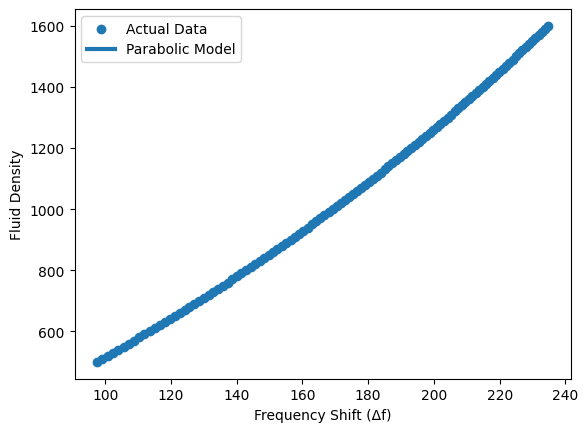

In [20]:
# =====================================================
# CELL 12: Visualize Model Fit
# =====================================================
# This graph compares experimental data with
# predicted parabolic regression curve

plt.scatter(X, y, label="Actual Data")

plt.plot(X, y_pred, linewidth=3, label="Parabolic Model")

plt.xlabel("Frequency Shift (Δf)")
plt.ylabel("Fluid Density")

plt.legend()

plt.show()

In [22]:
# =====================================================
# Predict Density for New Frequency Shift
# =====================================================

# create dataframe with same column name used in training
freq_shift = pd.DataFrame([[150]], columns=['∆f'])

# convert to polynomial features
freq_poly = poly.transform(freq_shift)

# predict density
predicted_density = model.predict(freq_poly)

print("Predicted Density:", predicted_density[0])

Predicted Density: 850.7878387609668


In [23]:

# CELL: Display Prediction Table

# assume reference frequency = 1000 (example)
reference_freq = 1000

# create dataframe for prediction
data_display = data.copy()

# calculate predicted density
data_display['Predicted Density'] = model.predict(X_poly)

# calculate input frequency (example)
data_display['Input Frequency'] = reference_freq - data_display['∆f']

# rearrange columns for display
result_table = data_display[['Input Frequency','∆f','Density of Fluid','Predicted Density']]

# display first 10 rows
result_table.head(10)

,Input Frequency,∆f,Density of Fluid,Predicted Density
0,902.47,97.53,500,503.683002
1,900.83,99.17,510,513.201615
2,899.20,100.80,520,522.747258
3,897.58,102.42,530,532.318371
4,895.97,104.03,540,541.913402
5,894.36,105.64,550,551.591175
6,892.77,107.23,560,561.229933
7,891.19,108.81,570,570.888010
8,889.61,110.39,580,580.625775
9,888.05,111.95,590,590.318456


In [24]:

# CELL: Display Final Learned Equation used by model

b0 = model.intercept_
b1 = model.coef_[1]
b2 = model.coef_[2]

print("Parabolic Model Equation:")
print(f"Density = {b0:.4f} + ({b1:.4f} * Δf) + ({b2:.6f} * Δf²)")

Parabolic Model Equation:
Density = 91.9858 + (2.6646 * Δf) + (0.015960 * Δf²)


The machine learning model learns the parabolic relationship between frequency shift and fluid density and predicts density values accurately from measured frequency shifts.

Frequency Shift ↑ → Density ↑

because heavier fluids change the vibration frequency more.

the relation between Δf and density is not straight, it is curved (parabolic).

So we trained a Polynomial Regression model (degree = 2).

The model learns this parabolic equation:

𝜌
=
𝑏
0
+
𝑏
1
(
Δ
𝑓
)
+
𝑏
2
(
Δ
𝑓
)
2
ρ=b
0
	​

+b
1
	​

(Δf)+b
2
	​

(Δf)
2

Where:

𝜌
ρ = density
Δ
𝑓
Δf = frequency shift
𝑏
0
,
𝑏
1
,
𝑏
2
b
0
	​

,b
1
	​

,b
2
	​

 = coefficients learned from the data

Now when you give a new Δf, the model predicts the density automatically.

In [25]:

# Check Model Accuracy

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# predict using trained model
y_pred = model.predict(X_poly)

# calculate accuracy metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("Model Accuracy (R² Score):", r2)
print("Model Error (RMSE):", rmse)

Model Accuracy (R² Score): 0.9999806903534286
Model Error (RMSE): 1.407997531246417


In [27]:
# =====================================================
# CELL: User Input Prediction
# =====================================================

# take input from user
delta_f = float(input("Enter Frequency Shift (Δf): "))

# convert to dataframe
input_df = pd.DataFrame([[delta_f]], columns=['∆f'])

# transform to polynomial features
input_poly = poly.transform(input_df)

# predict density
predicted_density = model.predict(input_poly)

print("Predicted Density:", predicted_density[0])

Enter Frequency Shift (Δf): 100
Predicted Density: 518.0516822844423


In [32]:
# CELL: Take Frequency as Input and Predict Density
# Formula Used: frequency Shift (Δf) = Reference Frequency - Input Frequency

# Set reference frequency
reference_freq = 1000

# Take frequency input from user
input_freq = float(input("Enter Measured Frequency: "))

# Calculate frequency shift
delta_f = reference_freq - input_freq

# Create dataframe with same column name used in training
input_df = pd.DataFrame([[delta_f]], columns=['∆f'])

# Convert into polynomial features
input_poly = poly.transform(input_df)

# Predict density
predicted_density = model.predict(input_poly)

# Display results
print("Reference Frequency:", reference_freq)
print("Measured Frequency:", input_freq)
print("Frequency Shift (Δf):", delta_f)
print("Predicted Density:", predicted_density[0])

Enter Measured Frequency: 768
Reference Frequency: 1000
Measured Frequency: 768.0
Frequency Shift (Δf): 232.0
Predicted Density: 1569.230820088259
